Taken From https://forum.image.sc/t/pyimagej-on-google-colab/32804

In [ ]:
import os       #importing os to set environment variable
def install_java():
  !apt-get install -y openjdk-8-jdk-headless -qq > /dev/null      #install openjdk
  os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"     #set environment variable
  !java -version       #check java version
install_java()

openjdk version "11.0.19" 2023-04-18
OpenJDK Runtime Environment (build 11.0.19+7-post-Ubuntu-0ubuntu120.04.1)
OpenJDK 64-Bit Server VM (build 11.0.19+7-post-Ubuntu-0ubuntu120.04.1, mixed mode, sharing)


In [ ]:
!sudo apt-get install maven
!pip install imglyb==0.3.5
!pip install pyimagej
!wget https://anaconda.org/conda-forge/pyjnius/1.2.0/download/linux-64/pyjnius-1.2.0-py36hc2cfd8d_0.tar.bz2 && tar -xjf pyjnius-1.2.0-py36hc2cfd8d_0.tar.bz2 -C /usr/local
os.environ["PYJNIUS_JAR"] = "/usr/local/share/pyjnius/pyjnius.jar"


In [ ]:
import imagej;
ij = imagej.init()


In [ ]:
from skimage import io
import numpy as np


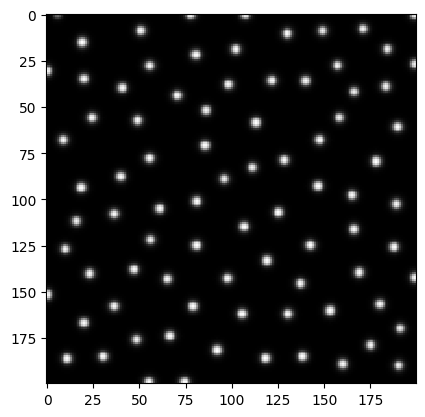

In [ ]:
path = '/content/drive/Shareddrives/Summer_2023_VCell_Ml/Summer 2023  Image analysis/ui_100_scan/ui_100_scan_tif/ui=0.07191919191919192.csv.tif'
img = io.imread(path)
ij.py.show(img, cmap = "gist_gray")


ImageJ Analysis Workflow adapted from https://pyimagej.readthedocs.io/en/latest/Classic-Segmentation.html

In [ ]:
import scyjava as sj
from collections import defaultdict
from pandas import DataFrame

In [ ]:
# Select Image

jslice = ij.py.to_java(img)

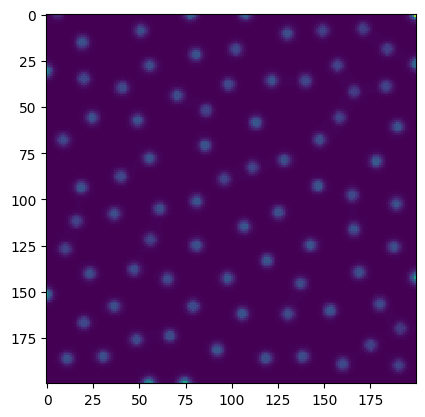

In [ ]:
# preprocess with edge-preserving smoothing. (unnecessary for our sim results)
HyperSphereShape = sj.jimport("net.imglib2.algorithm.neighborhood.HyperSphereShape")
smoothed = ij.op().run("create.img", jslice)
ij.op().run("filter.median", ij.py.jargs(smoothed, img, HyperSphereShape(5)))
ij.py.show(smoothed)

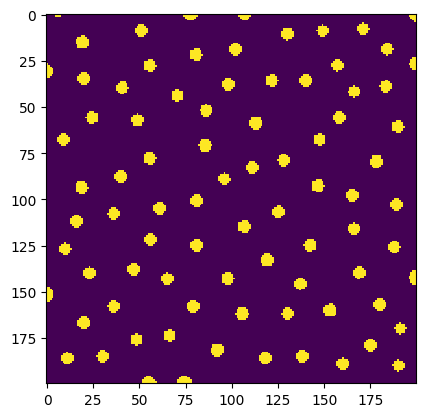

In [ ]:
# threshold to binary mask.
mask = ij.op().run("threshold.otsu", smoothed)
ij.py.show(mask)

In [ ]:
# # clean up the binary mask (Unnecessary for sim images).
# mask = ij.op().run("morphology.dilate", mask, HyperSphereShape(1))
# mask = ij.op().run("morphology.fillHoles", mask)
# ij.py.show(mask)

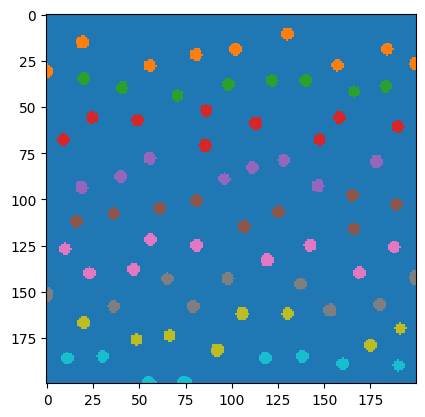

In [ ]:
# Watershed: mask to labeling.
use_eight_connectivity = True
draw_watersheds = False
sigma = 10
args = ij.py.jargs(None, mask, use_eight_connectivity, draw_watersheds, sigma, mask)
labeling = ij.op().run("image.watershed", args)
ij.py.show(labeling.getIndexImg(), cmap='tab10')

In [ ]:
# calculate statistics.

from collections import defaultdict
from pandas import DataFrame

Regions = sj.jimport("net.imglib2.roi.Regions")
LabelRegions = sj.jimport("net.imglib2.roi.labeling.LabelRegions")

def compute_stats(region, img, stats):
    samples = Regions.sample(region, img)
    stats["area"].append(ij.op().run("stats.size", samples).getRealDouble())
    stats["mean"].append(ij.op().run("stats.mean", samples).getRealDouble())
    min_max = ij.op().run("stats.minMax", samples)
    stats["min"].append(min_max.getA().getRealDouble())
    stats["max"].append(min_max.getB().getRealDouble())
    centroid = ij.op().run("geom.centroid", region)
    stats["centroid"].append(tuple(centroid.getDoublePosition(d) for d in range(centroid.numDimensions())))
    stats["median"].append(ij.op().run("stats.median", samples).getRealDouble())
    stats["skewness"].append(ij.op().run("stats.skewness", samples).getRealDouble())
    stats["kurtosis"].append(ij.op().run("stats.kurtosis", samples).getRealDouble())

regions = LabelRegions(labeling)
stats_ops = defaultdict(list)
for region in regions:
    compute_stats(region, jslice, stats_ops)
df_ops = DataFrame(stats_ops)
df_ops

,area,mean,min,max,centroid,median,skewness,kurtosis
0,37.0,76.324324,29.0,162.0,"(175.0, 179.0)",76.0,0.489921,1.834536
1,37.0,75.837838,29.0,161.0,"(16.0, 112.0)",75.0,0.495509,1.839066
2,37.0,76.810811,30.0,162.0,"(56.0, 122.0)",77.0,0.487783,1.827846
3,12.0,78.416667,31.0,139.0,"(189.91666666666666, 168.91666666666666)",70.0,0.375172,1.786300
4,37.0,80.270270,29.0,165.0,"(47.0, 138.0)",76.0,0.448159,1.787625
...,...,...,...,...,...,...,...,...
83,36.0,87.388889,28.0,168.0,"(168.97222222222223, 139.91666666666666)",81.5,0.325565,1.716280
84,39.0,84.948718,29.0,169.0,"(113.0, 58.84615384615385)",76.0,0.385239,1.732255
85,34.0,86.617647,32.0,163.0,"(66.5, 174.0)",71.0,0.323053,1.724057
86,37.0,86.945946,34.0,170.0,"(81.0, 125.0)",87.0,0.371270,1.706847
